Y shape: (296, 500, 3)
X shape: (296, 500, 37)
Before size: (208, 3)
After size: (88, 3)


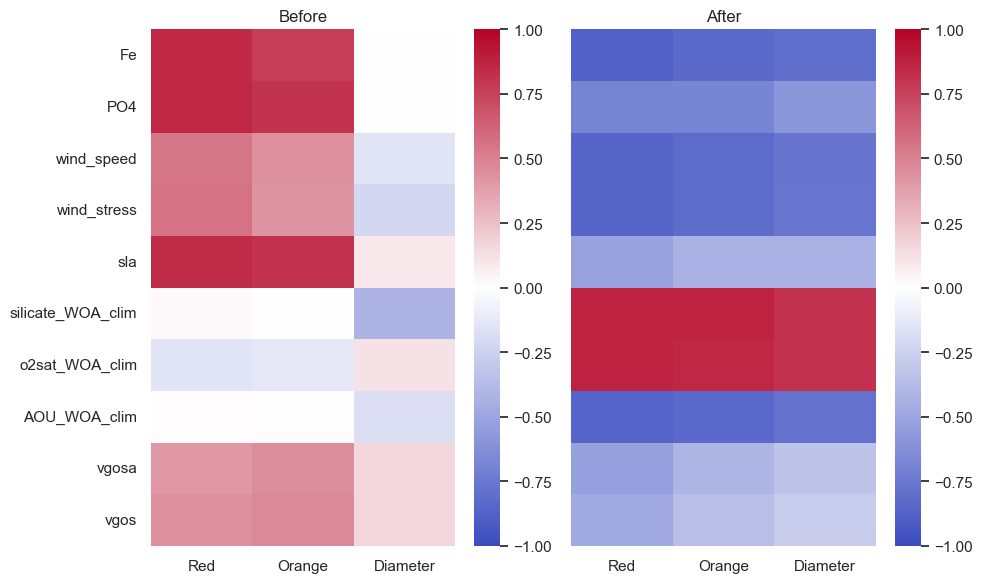

In [13]:
# ============================================================
# SETUP
# ============================================================
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="white")

# ============================================================
# LOAD DATA
# ============================================================

Y_r = pyreadr.read_r("../../y_arr.rds")
X_r = pyreadr.read_r("../../x_arr.rds")

Y = np.array(list(Y_r.values())[0])   # (T, N, 3)
X = np.array(list(X_r.values())[0])   # (T, N, p)

T, N, D = Y.shape
p = X.shape[2]

cp = 208

print("Y shape:", Y.shape)
print("X shape:", X.shape)

# ============================================================
# TIME-LEVEL AGGREGATION
# ============================================================
Y_mean = Y.mean(axis=1)   # (T, 3)
X_mean = X.mean(axis=1)   # (T, p)

# ============================================================
# SPLIT BEFORE / AFTER
# ============================================================
Y_before = Y_mean[:cp]
Y_after  = Y_mean[cp:]

X_before = X_mean[:cp]
X_after  = X_mean[cp:]

print("Before size:", Y_before.shape)
print("After size:", Y_after.shape)

# ============================================================
# CORRELATION
# ============================================================
corr_before = np.zeros((3, p))
corr_after  = np.zeros((3, p))

for j in range(3):
    for k in range(p):

        yb = Y_before[:, j]
        xb = X_before[:, k]

        ya = Y_after[:, j]
        xa = X_after[:, k]

        mask_b = ~np.isnan(yb) & ~np.isnan(xb)
        mask_a = ~np.isnan(ya) & ~np.isnan(xa)

        if np.sum(mask_b) < 10:
            corr_before[j, k] = np.nan
        else:
            corr_before[j, k] = spearmanr(yb[mask_b], xb[mask_b]).correlation

        if np.sum(mask_a) < 10:
            corr_after[j, k] = np.nan
        else:
            corr_after[j, k] = spearmanr(ya[mask_a], xa[mask_a]).correlation

# ============================================================
# VARIABLE NAMES
# ============================================================
colnames = [
    "p1","p2","p3","p4","sss","sst","Fe","PP","Si","NO3",
    "CHL","PHYC","PO4","O2","vgosa","vgos","sla","ugosa","ugos",
    "wind_stress","eastward_wind","surface_downward_eastward_stress",
    "wind_speed","surface_downward_northward_stress","northward_wind",
    "ftle_bw_sla","disp_bw_sla","AOU_WOA_clim","density_WOA_clim",
    "o2sat_WOA_clim","oxygen_WOA_clim","salinity_WOA_clim",
    "conductivity_WOA_clim","nitrate_WOA_clim","phosphate_WOA_clim",
    "silicate_WOA_clim","par"
]

# ============================================================
# SELECT VARIABLES WITH LARGEST CHANGE
# ============================================================
corr_diff = corr_after - corr_before
change_magnitude = np.nanmean(np.abs(corr_diff), axis=0)

top_k = 10
top_idx = np.argsort(change_magnitude)[-top_k:]
top_idx = top_idx[::-1]
order = np.argsort(-change_magnitude[top_idx])
top_idx = top_idx[order]
x_labels = np.array(colnames)[top_idx]

# ============================================================
# PREPARE MATRICES (transpose for plotting)
# ============================================================
corr_b = corr_before[:, top_idx].T
corr_a = corr_after[:, top_idx].T

y_labels = ["Red", "Orange", "Diameter"]

# ============================================================
# CUSTOM COLORMAP (WHITE CENTER!)
# ============================================================
cmap = LinearSegmentedColormap.from_list(
    "coolwarm_white",
    ["#3B4CC0", "#FFFFFF", "#B40426"]
)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.heatmap(
    corr_b,
    ax=axes[0],
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=y_labels,
    yticklabels=x_labels,
    cbar=True
)
axes[0].set_title("Before")

sns.heatmap(
    corr_a,
    ax=axes[1],
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=y_labels,
    yticklabels=False,
    cbar=True
)
axes[1].set_title("After")

plt.tight_layout()
plt.show()

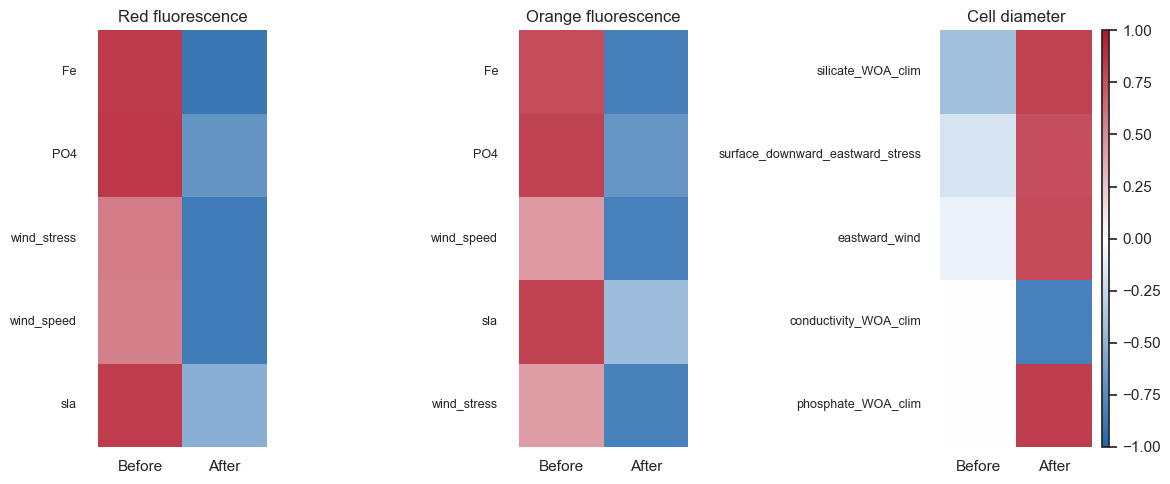

In [20]:
# ============================================================
# FUNCTION: build panel for one Y (top change only)
# ============================================================
def build_panel_top(j, corr_before, corr_after, colnames, top_k=5):

    before = corr_before[j, :]
    after  = corr_after[j, :]

    change = np.abs(after - before)

    idx = np.argsort(-change)[:top_k]

    mat = np.vstack([
        before[idx],
        after[idx]
    ]).T   # shape: (5,2)

    labels = list(np.array(colnames)[idx])

    return mat, labels


# ============================================================
# BUILD PANELS
# ============================================================
panels = []
labels_all = []

for j in range(3):
    mat, labels = build_panel_top(j, corr_before, corr_after, colnames)
    panels.append(mat)
    labels_all.append(labels)

y_titles = ["Red fluorescence", "Orange fluorescence", "Cell diameter"]

# ============================================================
# COLORMAP
# ============================================================
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "strong_white",
    ["#2166AC", "#FFFFFF", "#B2182B"]
)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for j in range(3):
    sns.heatmap(
        panels[j],
        ax=axes[j],
        cmap=cmap,
        center=0,
        vmin=-1,
        vmax=1,
        xticklabels=["Before", "After"],
        yticklabels=False,
        cbar=False
    )

    for i, var in enumerate(labels_all[j]):
        axes[j].text(
            -0.25,
            i + 0.5,
            var,
            ha='right',
            va='center',
            fontsize=9
        )

    axes[j].set_title(y_titles[j])

# ============================================================
# SINGLE COLORBAR
# ============================================================
from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.1)

plt.colorbar(axes[-1].collections[0], cax=cax)

plt.tight_layout()
plt.show()

In [16]:
neg_to_pos

array([29, 35, 36], dtype=int64)